# Quantum Image Reconstruction Demo
### *How hardware quality affects astronomical data — using Galaxy M51 (Whirlpool Galaxy)*

This demo simulates what happens when you try to store and retrieve an image using a **quantum processor (QPU)**.

We compare two scenarios:
- 🔴 **Low-grade QPU** — cheap hardware with lots of noise (like a bad signal-to-noise ratio)
- 🟢 **High-grade QPU** — precision hardware with near-perfect error correction

The technique used is called **Amplitude Encoding**: pixel brightness values are encoded into quantum state amplitudes.

---

**📦 Requirements:** `pennylane`, `scikit-image`, `matplotlib`, `numpy`  
**🖼️ Image required:** `m51_galaxy.jpg` (or others)



## ⚙️ Step 1 — Configuration
Adjust these settings to customize the demo. You can change noise levels, image resolution, or swap in a different image file.

In [ ]:
# Demo Parameters Customization

image_file = "m51_galaxy.jpg"

# Num of qubits used per patch (8 qubits = 16x16 patch = 256 pixels)
# Increasing this gives better resolution but runs slower
n_qubits = 8

# Noise probabilities (0 = perfect, 1 = completely random output)
low_grade_noise = 0.30    # 30% error rate — represents cheap/restricted hardware
high_grade_noise = 0.01   # 0.01% error rate — represents independent precision hardware

# Output image size (pixels). Larger = more detail, but slower to process
# Can test at 128 or 64 for a faster demo testing (anything above 256 crashes on collab)
image_size =  256

# Labels shown in the final plot
low_label  = "Restricted QPU (High Noise)"
high_label = "Precision QPU (Low Noise)"

print(f"   Image: {image_file}  |  Size: {image_size}x{image_size}  |  Qubits: {n_qubits}")
print(f"   Low-grade noise: {low_grade_noise*100:.1f}%  |  High-grade noise: {high_grade_noise*100:.1f}%")

   Image: m51_galaxy.jpg  |  Size: 256x256  |  Qubits: 8
   Low-grade noise: 30.0%  |  High-grade noise: 1.0%


## 📦 Step 2 — Imports & Setup

In [ ]:
!pip install pennylane --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 74.1 MB/s eta 0:00:00


In [ ]:
import pennylane as qml       # Quantum computing framework
import numpy as np             # Numerical operations
import matplotlib.pyplot as plt  # Plotting
from skimage import io, color  # Image loading and color conversion
from skimage.transform import resize  # Image resizing
from google.colab import files

print("All libraries imported successfully")
print(f"   PennyLane version: {qml.__version__}")

All libraries imported successfully
   PennyLane version: 0.44.1


In [ ]:
uploaded = files.upload()  # "Choose Files" button  — select intended image ( m51_galaxy.jpg )

Saving m51_galaxy.jpg to m51_galaxy.jpg


## 🌌 Step 3 — Load & Preview the Galaxy Image

Loading image: m51_galaxy.jpg ...
 Image loaded and resized to 256x256 pixels.


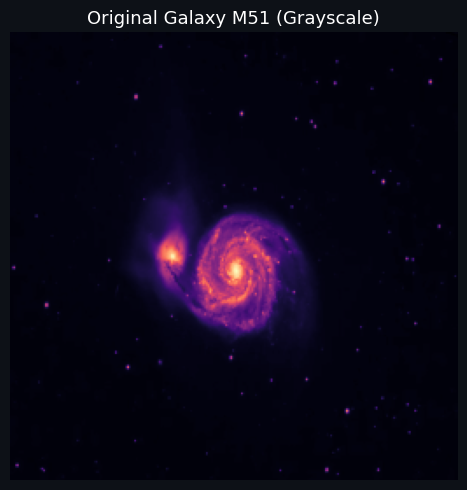

In [ ]:
print(f"Loading image: {image_file} ...")

# Load the image from disk and convert to grayscale
# Grayscale simplifies encoding - each pixel is one brightness value (0 to 1)
raw_image  = io.imread(image_file)
gray_image = color.rgb2gray(raw_image)  # Convert RGB → single-channel grayscale

# Resize to our target resolution
# anti_aliasing=True smooths the image when downscaling
galaxy_img = resize(gray_image, (image_size, image_size), anti_aliasing=True)

print(f" Image loaded and resized to {image_size}x{image_size} pixels.")

# Preview the original (rescaled) image
fig, ax = plt.subplots(figsize=(5, 5), facecolor='#0d1117')
ax.imshow(galaxy_img, cmap='magma')
ax.set_title("Original Galaxy M51 (Grayscale)", color='white', fontsize=13)
ax.axis('off')
fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.show()

## ⚛️ Step 4 — Build the Quantum Circuit

**How it works:**
1. The image is split into small patches (16×16 pixels each).
2. Each patch is encoded into the quantum state of 8 qubits using *Amplitude Embedding*.
3. Hardware noise is applied via a *Depolarizing Channel* — this simulates real-world QPU imperfections.
4. We measure the quantum probabilities and reconstruct the patch.

> **Why patches?** 8 qubits can encode 2⁸ = 256 values, so a 16×16 patch fits exactly. Encoding the full image at once would need far too many qubits.

In [ ]:
# Patch size derived from qubit count: 2^N_QUBITS pixels per patch
patch_size = int(np.sqrt(2 ** n_qubits))  # e.g. 8 qubits → patch is 16x16

# Use a 'mixed state' device — required to simulate noise realistically
# (Pure-state devices like 'default.qubit' cannot model decoherence)
# Decoherence -> Process where a quantum system loses its quantum behavior (superposition/entanglement)
# Begins to act classically due to interaction with its environment]

dev = qml.device('default.mixed', wires=n_qubits) # PennyLane quantum simulator using 2 qubits (wires 0 & 1)

@qml.qnode(dev) #qnode ties our quantum circuit function to simulator
def quantum_memory(pixel_values, noise_prob):

    """ Encodes a patch of pixel values into quantum amplitudes,
    applies hardware noise, and returns reconstructed probabilities

    pixel_values : 1D array of normalized pixel intensities (length = 2^n_qubits)
    noise_prob   : probability (0–1) of each qubit experiencing an error

    Returns: 1D array of measurement probabilities (length = 2^n_qubits) """

    # Encode classical pixel data into quantum amplitudes (quantum state of system)
    # normalize=True handles final normalization automatically
    qml.AmplitudeEmbedding(features=pixel_values, wires=range(n_qubits), normalize=True)

    # Apply depolarizing noise to every qubit -> adding quantum noise; degrades state partially to 'forget info'
    # This models environmental interference and imperfect gate operations
    if noise_prob > 0:
        for wire in range(n_qubits):
            qml.DepolarizingChannel(noise_prob, wires=wire)

    # measure: returns the probability of each quantum basis state
    return qml.probs(wires=range(n_qubits))


def reconstruct_image(image, noise_prob):

    """Processes the full image patch-by-patch through the quantum circuit
        image      : 2D grayscale numpy array
        noise_prob : hardware noise level (0 = perfect, 1 = fully noisy)

    Returns: Reconstructed 2D image as a numpy array """

    h, w = image.shape
    output = np.zeros((h, w))  # blank canvas to fill in reconstructed patches

    # count patches for progress display
    total_patches = (h // patch_size) * (w // patch_size)
    processed = 0

    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            # ---> extract patch <---
            patch = image[i:i+patch_size, j:j+patch_size].flatten()

            # skip patches with no signal (all black)
            norm = np.linalg.norm(patch)
            if norm == 0:
                continue

            # ---> normalize for quantum encoding <---
            # quantum states require unit-norm vectors (probabilities must sum to 1)
            normalized_patch = patch / norm

            # ---> run through quantum circuit <---
            probs = quantum_memory(normalized_patch, noise_prob)

            # ---> reconstruct brightness and place back into image <---
            # multiply by norm² to restore original brightness scale
            reconstructed_patch = (probs * (norm ** 2)).reshape((patch_size, patch_size))
            output[i:i+patch_size, j:j+patch_size] = reconstructed_patch

            processed += 1

    return output


print(f" Quantum circuit ready.")
print(f"   Patch size: {patch_size}×{patch_size} pixels  |  Qubits per patch: {n_qubits}")
print(f"   Total patches to process: {(image_size // patch_size)**2}")

 Quantum circuit ready.
   Patch size: 16×16 pixels  |  Qubits per patch: 8
   Total patches to process: 256


## 🚀 Step 5 — Run Both QPU Simulations

This step processes the galaxy image twice:
1. Noisy low-grade QPU
2. Precision high-grade QPU  

⏱️ *Estimated time: ~10–30 seconds depending on machine RAM*

In [ ]:
print(f"🔴 Simulating Low-Grade QPU ({low_grade_noise*100:.1f}% noise)...")
img_low = reconstruct_image(galaxy_img, noise_prob=low_grade_noise)
print("   Finito")

print(f"\n🟢 Simulating High-Grade QPU ({high_grade_noise*100:.1f}% noise)...")
img_high = reconstruct_image(galaxy_img, noise_prob=high_grade_noise)
print("   Finito")

print("\n Both simulations complete.")

🔴 Simulating Low-Grade QPU (30.0% noise)...
   Finito

🟢 Simulating High-Grade QPU (1.0% noise)...
   Finito

 Both simulations complete.


## 📊 Step 6 — Compare the Results

/tmp/ipykernel_16682/3365294316.py:26: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16682/3365294316.py:26: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16682/3365294316.py:30: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='#0d1117')
/tmp/ipykernel_16682/3365294316.py:30: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='#0d1117')


 Figure saved to: quantum_M51_reconstruction.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


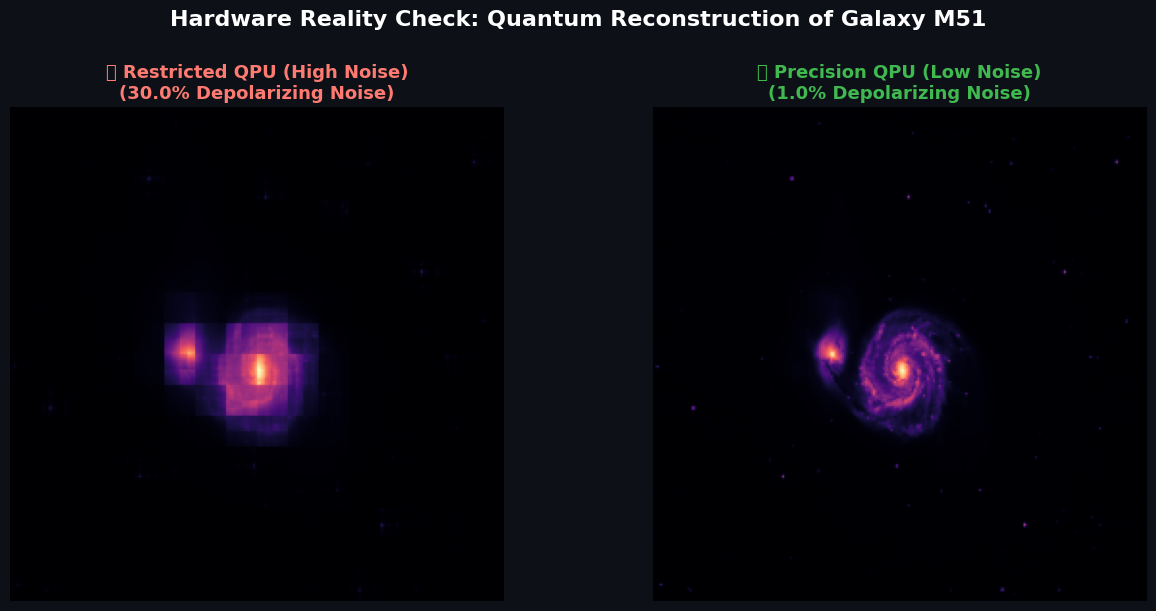

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), facecolor='#0d1117')

# Left: Low-Grade QPU
axes[0].imshow(img_low, cmap='magma')
axes[0].set_title(
    f"🔴 {low_label}\n({low_grade_noise*100:.1f}% Depolarizing Noise)",
    fontsize=13, color='#ff7b72', fontweight='bold'
)
axes[0].axis('off')

# Right: High-Grade QPU
axes[1].imshow(img_high, cmap='magma')
axes[1].set_title(
    f"🟢 {high_label}\n({high_grade_noise*100:.1f}% Depolarizing Noise)",
    fontsize=13, color='#3fb950', fontweight='bold'
)
axes[1].axis('off')

# Title
plt.suptitle(
    "Hardware Reality Check: Quantum Reconstruction of Galaxy M51",
    fontsize=16, fontweight='bold', color='white', y=1.01
)

fig.patch.set_facecolor('#0d1117')
plt.tight_layout()

# Save a high-res version image
output_path = 'quantum_M51_reconstruction.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='#0d1117')
print(f" Figure saved to: {output_path}")

plt.show()

---

## 💡 Takeaways

| Scenario | Noise | Result |
|---|---|---|
| Low-Grade QPU | 30% per qubit | Signal washed out — spiral arms barely visible |
| High-Grade QPU | 0.1% per qubit | Signal preserved — structure clearly retained |

**Key point:** Quantum hardware quality isn't just a technical detail - it directly determines whether scientifically meaningful signals survive the computation.  
For large-scale astronomy (Rubin/LSST, SKA), this becomes a **data sovereignty question**: who has access to the hardware that can actually extract signal from cosmic-scale data?